In [10]:
# imports and connection
import snowflake.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from snowflake_config import SNOWFLAKE_CONFIG

# connect to snowflake
conn = snowflake.connector.connect(**SNOWFLAKE_CONFIG)
cursor = conn.cursor()

print("Connected successfully!")

Connected successfully!


In [11]:
# how many distinct categories does our dataset have? 
def run_query(sql):
    cursor.execute(sql)
    df = cursor.fetch_pandas_all()
    return df

cats_df = run_query("""
    select 
        category_code,
        count(*) as purchases
    from fct_purchases
    where category_code is not null
    group by 1
    order by 2 desc
    limit 20
""")
cats_df

,CATEGORY_CODE,PURCHASES
0,construction.tools.light,2313085
1,electronics.smartphone,734123
2,sport.bicycle,263991
3,electronics.audio.headphone,207255
4,electronics.clocks,186993
5,appliances.personal.massager,186395
6,apparel.shoes,152741
7,appliances.kitchen.refrigerators,137841
8,appliances.environment.vacuum,127963
9,appliances.kitchen.washer,114863


In [12]:
# check top level categories
toplevel_df = run_query("""
    select
        split_part(category_code, '.', 1) as top_category,
        count(*) as purchases
    from fct_purchases
    where category_code is not null
    group by 1
    order by 2 desc
""")

toplevel_df

,TOP_CATEGORY,PURCHASES
0,construction,2442247
1,electronics,1341139
2,appliances,925761
3,apparel,455370
4,sport,316243
5,computers,202396
6,furniture,197485
7,kids,93757
8,auto,54205
9,accessories,36854


In [13]:
# basket data
basket_df = run_query("""
    select
        user_session,
        split_part(category_code, '.', 1) as top_category
    from fct_purchases
    where category_code is not null
    group by 1, 2
""")

print(f"Total rows: {len(basket_df):,}")
print(f"Unique sessions: {basket_df['USER_SESSION'].nunique():,}")
basket_df.head(10)

Total rows: 4,993,448
Unique sessions: 4,823,244


,USER_SESSION,TOP_CATEGORY
0,970c29f3-e60c-4d65-989e-d7365f15bfe8,electronics
1,435c7599-77c3-4e8d-a857-4b7080c8e282,electronics
2,a51df01d-0edf-4899-8d11-5e55a43825e7,electronics
3,a65698ee-bfde-4289-84f0-0daf2a113112,electronics
4,071a80e0-1085-49a5-b011-2cc99d4e0451,electronics
5,5143682e-cab9-4ccc-a8a8-6a395e7c4b10,computers
6,48004c9a-762b-4e01-9481-194c52d38a19,electronics
7,cba27a66-c9b3-41f6-8d9e-841d57129bb5,computers
8,bbfe2222-ec10-4ea5-b668-555ef9aee373,appliances
9,05a755ff-cac7-48a2-b7bd-dc83933d3286,electronics


In [5]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

print("mlxtend loaded successfully")

mlxtend loaded successfully


In [18]:
# group categories into lists per session
transactions = basket_df.groupby('USER_SESSION')['TOP_CATEGORY'].apply(list).tolist()

print(f"Total transactions: {len(transactions):,}")
print(f"Sample transaction: {transactions[0]}")
print(f"Sample transaction: {transactions[1]}")
print(f"Sample transaction: {transactions[2]}")

Total transactions: 4,823,244
Sample transaction: ['electronics']
Sample transaction: ['electronics']
Sample transaction: ['sport']


In [16]:
# check distribution of basket sizes
basket_sizes = basket_df.groupby('USER_SESSION')['TOP_CATEGORY'].nunique()

print("Basket size distribution:")
print(basket_sizes.value_counts().sort_index())
print(f"\nSessions with 2+ categories: {(basket_sizes >= 2).sum():,}")
print(f"Percentage of total: {(basket_sizes >= 2).sum() / len(basket_sizes) * 100:.1f}%")

Basket size distribution:
TOP_CATEGORY
1    4669053
2     140601
3      11618
4       1627
5        269
6         56
7         12
8          6
9          2
Name: count, dtype: int64

Sessions with 2+ categories: 154,191
Percentage of total: 3.2%


In [17]:
# switch to user level baskets as 3.2% is too litle
user_basket_df = run_query("""
    select
        user_id,
        split_part(category_code, '.', 1) as top_category
    from fct_purchases
    where category_code is not null
    group by 1, 2
""")

# check basket sizes at user level
user_basket_sizes = user_basket_df.groupby('USER_ID')['TOP_CATEGORY'].nunique()

print("User basket size distribution:")
print(user_basket_sizes.value_counts().sort_index())
print(f"\nUsers with 2+ categories: {(user_basket_sizes >= 2).sum():,}")
print(f"Percentage of total: {(user_basket_sizes >= 2).sum() / len(user_basket_sizes) * 100:.1f}%")

User basket size distribution:
TOP_CATEGORY
1     1365687
2      337884
3      113307
4       42769
5       17334
6        7211
7        2910
8        1163
9         467
10        124
11         25
12          2
Name: count, dtype: int64

Users with 2+ categories: 523,196
Percentage of total: 27.7%


In [19]:
# group categories into lists per user
user_transactions = (
    user_basket_df
    .groupby('USER_ID')['TOP_CATEGORY']
    .apply(list)
    .tolist()
)

print(f"Total users: {len(user_transactions):,}")
print(f"Sample user basket: {user_transactions[100]}")
print(f"Sample user basket: {user_transactions[200]}")
print(f"Sample user basket: {user_transactions[300]}")

Total users: 1,888,883
Sample user basket: ['apparel']
Sample user basket: ['construction']
Sample user basket: ['appliances']


In [20]:
# encode transactions into boolean matrix
te = TransactionEncoder()
te_array = te.fit_transform(user_transactions)
basket_encoded = pd.DataFrame(te_array, columns=te.columns_)

print(f"Matrix shape: {basket_encoded.shape}")
print(f"Categories: {list(basket_encoded.columns)}")

# run apriori — min support 0.01 means category pair 
# must appear in at least 1% of users
frequent_itemsets = apriori(
    basket_encoded,
    min_support=0.01,
    use_colnames=True
)

frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f"\nFrequent itemsets found: {len(frequent_itemsets):,}")
print(frequent_itemsets.sort_values('support', ascending=False).head(20))

Matrix shape: (1888883, 13)
Categories: ['accessories', 'apparel', 'appliances', 'auto', 'computers', 'construction', 'country_yard', 'electronics', 'furniture', 'kids', 'medicine', 'sport', 'stationery']

Frequent itemsets found: 36
     support                                 itemsets  length
5   0.461413                           (construction)       1
6   0.314423                            (electronics)       1
2   0.251696                             (appliances)       1
1   0.128410                                (apparel)       1
9   0.086828                                  (sport)       1
23  0.086338              (construction, electronics)       2
17  0.070009               (construction, appliances)       2
7   0.066884                              (furniture)       1
4   0.060408                              (computers)       1
18  0.055002                (electronics, appliances)       2
12  0.043635                  (construction, apparel)       2
10  0.034639          

In [21]:
rules = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=1.0
)

# clean up for display
rules = rules.sort_values('lift', ascending=False)
rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

print(f"Total rules found: {len(rules):,}")
print("\nTop 15 rules by lift:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15).to_string(index=False))

Total rules found: 56

Top 15 rules by lift:
              antecedents               consequents  support  confidence     lift
                    sport     construction, apparel 0.010188    0.117330 2.688918
    construction, apparel                     sport 0.010188    0.233472 2.688918
                  apparel       construction, sport 0.010188    0.079336 2.420813
      construction, sport                   apparel 0.010188    0.310857 2.420813
  electronics, appliances                   apparel 0.014251    0.259093 2.017700
                  apparel   electronics, appliances 0.014251    0.110978 2.017700
                    sport construction, electronics 0.014901    0.171621 1.987770
construction, electronics                     sport 0.014901    0.172593 1.987770
                  apparel  construction, appliances 0.017107    0.133225 1.902967
 construction, appliances                   apparel 0.017107    0.244361 1.902967
                    sport  construction, appliances 0

In [22]:
# create confidence matrix for visualization
categories = sorted(set(rules['antecedents'].unique()) | 
                   set(rules['consequents'].unique()))

# filter to single → single rules only for clean heatmap
single_rules = rules[
    ~rules['antecedents'].str.contains(',') & 
    ~rules['consequents'].str.contains(',')
].copy()

print(f"Single-to-single rules: {len(single_rules)}")
print(single_rules[['antecedents', 'consequents', 
                     'confidence', 'lift']].to_string(index=False))

Single-to-single rules: 14
antecedents consequents  confidence     lift
    apparel   furniture    0.115641 1.728982
  furniture     apparel    0.222019 1.728982
  computers     apparel    0.211649 1.648225
    apparel   computers    0.099566 1.648225
    apparel       sport    0.140320 1.616083
      sport     apparel    0.207522 1.616083
 appliances   furniture    0.086346 1.290980
  furniture  appliances    0.324935 1.290980
 appliances   computers    0.072838 1.205763
  computers  appliances    0.303486 1.205763
 appliances     apparel    0.137622 1.071738
    apparel  appliances    0.269752 1.071738
  computers electronics    0.315686 1.004015
electronics   computers    0.060651 1.004015


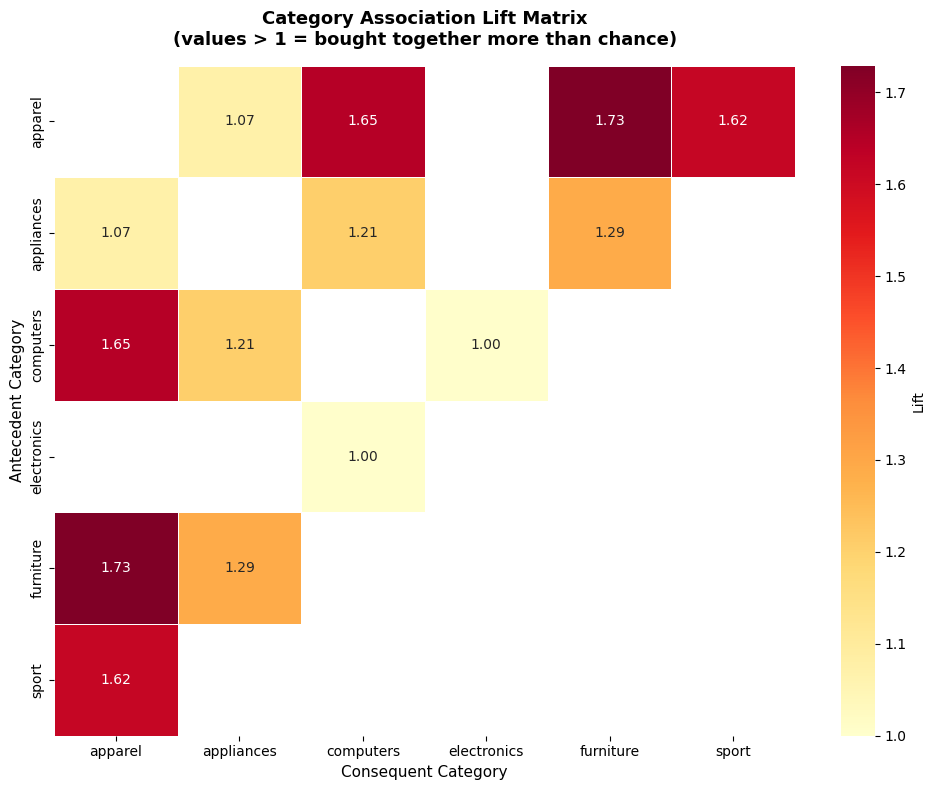

In [23]:
# pivot into matrix
all_cats = sorted(set(
    single_rules['antecedents'].tolist() + 
    single_rules['consequents'].tolist()
))

lift_matrix = pd.DataFrame(
    index=all_cats, 
    columns=all_cats, 
    dtype=float
)

for _, row in single_rules.iterrows():
    lift_matrix.loc[row['antecedents'], row['consequents']] = row['lift']

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    lift_matrix.astype(float),
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Lift'},
    vmin=1.0
)

ax.set_title(
    'Category Association Lift Matrix\n(values > 1 = bought together more than chance)',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('Consequent Category', fontsize=11)
ax.set_ylabel('Antecedent Category', fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
## Basket Analysis Findings

### Method
Association rules mining (Apriori algorithm) on user-level purchase history across 1.89M users. Minimum support: 1% of users.

### Key Associations Found
| If user buys...          | They also tend to buy... | Lift  |
|--------------------------|--------------------------|-------|
| Sport                    | Construction + Apparel   | 2.69x |
| Apparel                  | Construction + Sport     | 2.42x |
| Electronics + Appliances | Apparel                  | 2.02x |
| Apparel                  | Furniture                | 1.73x |

### User Segments Identified
**DIY Enthusiast:** Sport + Construction + Apparel buyers (lift 2.69)
Likely active, home-owning users. Cross-sell opportunity: show construction accessories to sport buyers and vice versa.

**Home Upgrader:** Electronics + Appliances + Apparel (lift 2.02)
Likely families or new homeowners. Bundle promotions across these categories could increase basket size.

**Home Decorator:** Apparel + Furniture (lift 1.73)
Style-conscious users. Recommend furniture when browsing apparel and vice versa.

### Recommendations
- Implement cross-category recommendations for top associated pairs
- Create targeted email campaigns based on user segment
- Test homepage personalization showing associated categories
- Priority: Sport/Construction/Apparel segment (highest lift at 2.69x)